In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print("Shape dataset:", df.shape)
print("\n5 data pertama:")
df.head()

Shape dataset: (5110, 12)

5 data pertama:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
print("Informasi Dataset:")
print(df.info())
print("\nStatistik Deskriptif:")
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Statistik Deskriptif:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [4]:
print("Jumlah Missing Values per Kolom:")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Persentase (%)': missing_percent
})
print(missing_df[missing_df['Missing Values'] > 0])

Jumlah Missing Values per Kolom:
     Missing Values  Persentase (%)
bmi             201        3.933464


In [5]:
print("Jumlah data duplikat:", df.duplicated().sum())
print("Jumlah total data:", len(df))

Jumlah data duplikat: 0
Jumlah total data: 5110


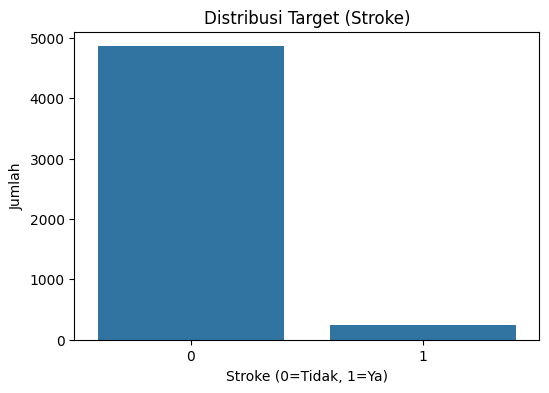

Distribusi target:
stroke
0    4861
1     249
Name: count, dtype: int64

Persentase:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df)
plt.title('Distribusi Target (Stroke)')
plt.xlabel('Stroke (0=Tidak, 1=Ya)')
plt.ylabel('Jumlah')
plt.show()

print("Distribusi target:")
print(df['stroke'].value_counts())
print("\nPersentase:")
print(df['stroke'].value_counts(normalize=True) * 100)

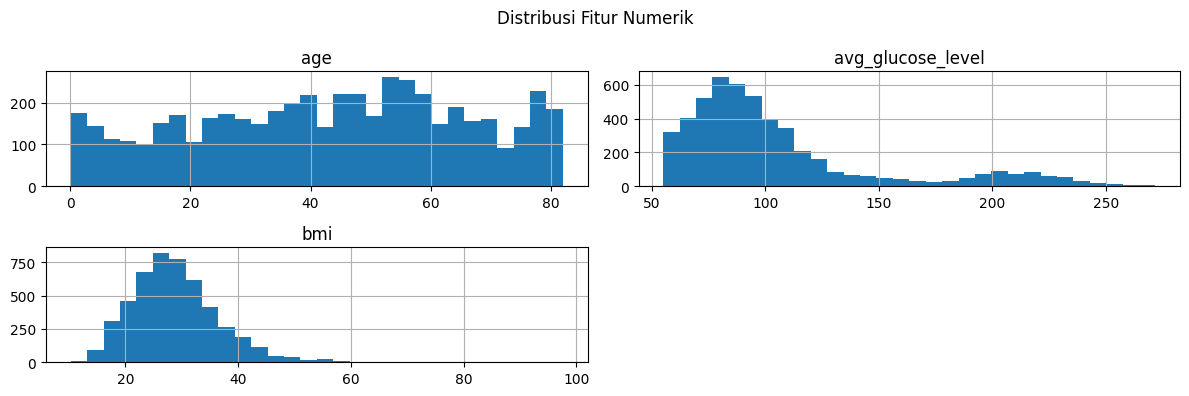

In [7]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
df[num_cols].hist(figsize=(12,4), bins=30)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

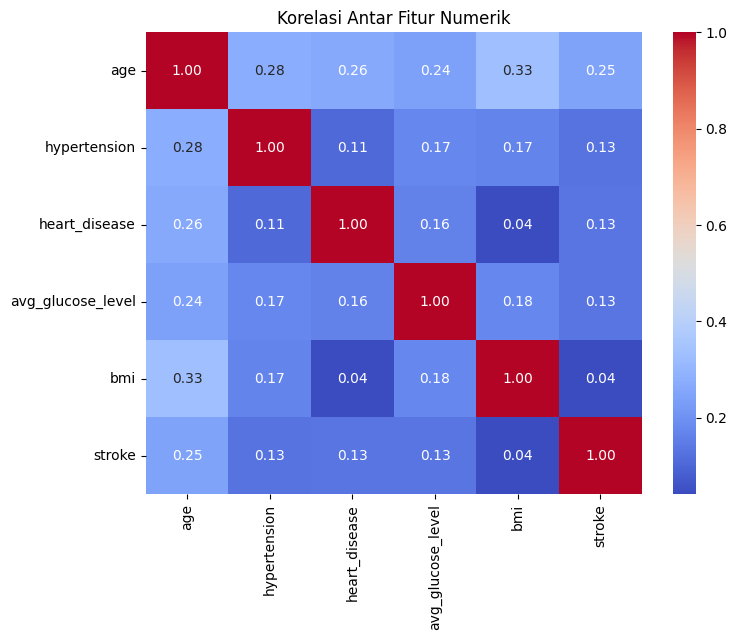

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['age', 'hypertension', 'heart_disease',
                'avg_glucose_level', 'bmi', 'stroke']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

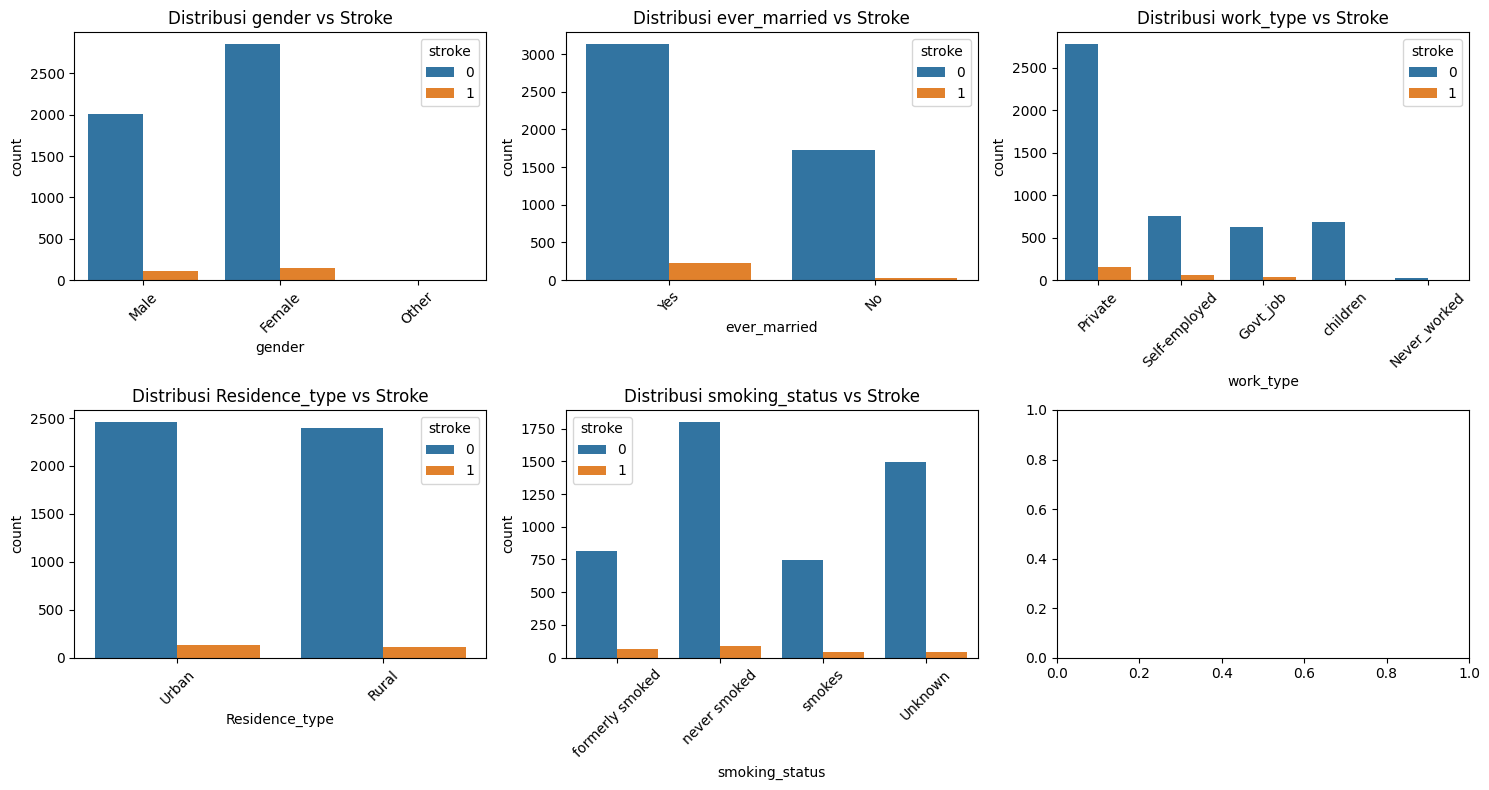

In [9]:
cat_cols = ['gender', 'ever_married', 'work_type',
            'Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='stroke', data=df, ax=axes[i])
    axes[i].set_title(f'Distribusi {col} vs Stroke')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
df = df.drop(columns=['id'])
print("Kolom id dihapus")

Kolom id dihapus


In [11]:
df = df[df['gender'] != 'Other']
print("Baris gender 'Other' dihapus")
print("Shape setelah hapus:", df.shape)

Baris gender 'Other' dihapus
Shape setelah hapus: (5109, 11)


In [12]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
print("\nMissing values setelah diisi:")
print(df.isnull().sum())


Missing values setelah diisi:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [13]:
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type',
            'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print("\nEncoding selesai")


Encoding selesai


In [14]:
X = df.drop(columns=['stroke'])
y = df['stroke']

In [15]:
scaler = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']
X[num_cols] = scaler.fit_transform(X[num_cols])
print("Scaling selesai")

Scaling selesai


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nUkuran data train: {X_train.shape}")
print(f"Ukuran data test: {X_test.shape}")


Ukuran data train: (4087, 10)
Ukuran data test: (1022, 10)


In [17]:
train_df = X_train.copy()
train_df['stroke'] = y_train.values
test_df = X_test.copy()
test_df['stroke'] = y_test.values

df_preprocessed = pd.concat([train_df, test_df], ignore_index=True)
df_preprocessed.to_csv('stroke_preprocessing.csv', index=False)
print("\nDataset preprocessed berhasil disimpan!")
print("Shape final:", df_preprocessed.shape)
df_preprocessed.head()


Dataset preprocessed berhasil disimpan!
Shape final: (5109, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,0.210956,0,0,1,2,1,-0.815590,0.550290,2,0
1,0,-0.629329,0,0,0,2,1,-0.484764,-0.995359,2,0
2,0,-0.363976,0,0,1,2,0,0.292832,-0.774552,2,0
3,1,-0.231299,0,0,1,2,0,0.056086,0.498335,2,0
4,1,-1.292712,0,0,0,0,1,-0.525621,0.355460,0,0
